# Quantum Ensemble Learning Tutorial

## Overview

This notebook demonstrates **quantum ensemble learning** for classification tasks using quantum cosine similarity classifiers. The approach combines multiple quantum classifiers through superposition to improve prediction accuracy and robustness.

### Key Concepts

1. **Quantum Cosine Classifier**: Measures similarity between quantum-encoded data points
2. **Quantum Ensemble**: Creates superpositions of different training data arrangements
3. **Random Unitary Ensemble**: Uses randomly sampled unitaries for more general transformations

### References

- **This work**: [arXiv:2506.02213](https://arxiv.org/abs/2506.02213)
- **Original ensemble work**: Macaluso et al. [IET Quantum Communication](https://ietresearch.onlinelibrary.wiley.com/doi/full/10.1049/qtc2.12087)
- **Original Code repository**: [GitHub](https://github.com/amacaluso/Quantum-algorithm-for-ensemble-using-bagging)

## 1. Setup and Initialization

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import numpy as np
import pandas as pd
import pickle
from collections import Counter
from sklearn import datasets
from sklearn.model_selection import train_test_split

from Utils import *
from modeling import *

/home/krhriss/QBioCode/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-23 13:40:51.672614: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-23 13:40:51.689471: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774291251.707736  108400 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774291251.713230  108400 cuda_blas.cc:1407] Un

In [3]:
# Set random seed for reproducibility
seed = 54321
n_shots = 8192
np.random.seed(seed)

In [4]:
# Setup directories
DIR_HOME = '.'
DIR_OUTPUT = os.path.join(DIR_HOME, 'experiments')
os.makedirs(DIR_OUTPUT, exist_ok=True)

FILE_PREDICTIONS = os.path.join(DIR_OUTPUT, 'predictions.pkl')
FILE_DATASETS = os.path.join(DIR_OUTPUT, 'datasets.pkl')

## 2. Configuration Parameters

Define experiment parameters:
- **TEST_SIZE**: Fraction of data used for testing (0.2 = 20%)
- **N_SPLITS**: Number of cross-validation splits
- **seed**: Random seed for reproducibility
- **n_shots**: Number of quantum measurements per circuit

In [5]:
TEST_SIZE = 0.2
N_SPLITS = 5

In [6]:
# Load or initialize storage objects
if os.path.exists(FILE_DATASETS):
    dataset = pickle.load(open(FILE_DATASETS, 'rb'))
else:
    dataset = {}

if os.path.exists(FILE_PREDICTIONS):
    predictions = pickle.load(open(FILE_PREDICTIONS, 'rb'))
else:
    predictions = {}

## 3. Dataset Generation

Generate synthetic blob datasets with:
- **2D feature space**: Easy to visualize
- **2 classes**: Binary classification problem
- **Varying parameters**: Different cluster centers, standard deviations, and sample sizes

In [7]:
dataset_name = 'blob'
rerun = False
dataset_sizes = [20]

if (rerun) or (dataset_name not in dataset.keys()):
    predictions[dataset_name] = {}
    dataset[dataset_name] = {}
    
    for n_size in dataset_sizes:
        for std in [0.3, 0.5]:
            for p1 in [0.3, 0.5, 1]:
                for p2 in [0.3, 0.5, 1]:
                    centers = [[p1, p2], [p2, p1]]
                    
                    for split in range(N_SPLITS):
                        X, y = datasets.make_blobs(
                            n_samples=n_size,
                            centers=centers,
                            n_features=2,
                            center_box=(0, 1),
                            cluster_std=std,
                            random_state=seed
                        )
                        
                        X_train, X_test, y_train, y_test = train_test_split(
                            X, y, stratify=y, random_state=seed, test_size=TEST_SIZE
                        )
                        
                        dataset[dataset_name][(split, n_size, std, p1, p2)] = (
                            pd.DataFrame(X_train),
                            pd.DataFrame(X_test),
                            pd.Series(y_train),
                            pd.Series(y_test)
                        )
    
    pickle.dump(dataset, open(FILE_DATASETS, 'wb'))

## 4. Classical Baselines

Run classical machine learning baselines for comparison.

### Random Forest with Grid Search

In [8]:
method = 'random_forest_gs'
dataset_name = 'blob'
rerun = False

if (rerun) or (dataset_name not in predictions.keys()) or (method not in predictions[dataset_name].keys()):
    if dataset_name not in predictions.keys():
        predictions[dataset_name] = {}
    predictions = run_random_forest(predictions, dataset, method, dataset_name, seed, TEST_SIZE, FILE_PREDICTIONS)

### Random Forest with Best Parameters

In [9]:
method = 'random_forest'
dataset_name = 'blob'
rerun = False

# Select best parameters from grid search
preds = predictions[dataset_name]['random_forest_gs']
params_map = dict(zip([str(x) for x in list(preds['best_params'])], list(preds['best_params'])))
best = dict(Counter([str(x) for x in list(preds['best_params'])]))
best = pd.DataFrame([best.keys(), best.values()], index=['param', 'cnt']).transpose()
params = params_map[best[best.cnt == max(best.cnt)]['param'].iloc[0]]

if (rerun) or (dataset_name not in predictions.keys()) or (method not in predictions[dataset_name].keys()):
    if dataset_name not in predictions.keys():
        predictions[dataset_name] = {}
    predictions = run_random_forest(predictions, dataset, method, dataset_name, seed, TEST_SIZE, FILE_PREDICTIONS, params=params)

### XGBoost with Grid Search

In [10]:
method = 'xgb_gs'
dataset_name = 'blob'
rerun = False

if (rerun) or (dataset_name not in predictions.keys()) or (method not in predictions[dataset_name].keys()):
    if dataset_name not in predictions.keys():
        predictions[dataset_name] = {}
    predictions = run_xgboost(predictions, dataset, method, dataset_name, seed, TEST_SIZE, FILE_PREDICTIONS)

Fitting 3 folds for each of 486 candidates, totalling 1458 fits


### XGBoost with Best Parameters

In [11]:
method = 'xgb'
dataset_name = 'blob'
rerun = False

# Select best parameters from grid search
preds = predictions[dataset_name]['xgb_gs']
params_map = dict(zip([str(x) for x in list(preds['best_params'])], list(preds['best_params'])))
best = dict(Counter([str(x) for x in list(preds['best_params'])]))
best = pd.DataFrame([best.keys(), best.values()], index=['param', 'cnt']).transpose()
params = params_map[best[best.cnt == max(best.cnt)]['param'].iloc[0]]

if (rerun) or (dataset_name not in predictions.keys()) or (method not in predictions[dataset_name].keys()):
    if dataset_name not in predictions.keys():
        predictions[dataset_name] = {}
    predictions = run_xgboost(predictions, dataset, method, dataset_name, seed, TEST_SIZE, FILE_PREDICTIONS, params=params)

## 5. Quantum Cosine Classifier

The quantum cosine classifier measures similarity between quantum states using:

1. **State Preparation**: Encode classical data as quantum states
2. **Controlled-SWAP Test**: Measure overlap between training and test states
3. **Hadamard Interference**: Extract similarity information
4. **Measurement**: Obtain classification probability

**Key Parameters**:
- `n_train`: Number of training samples (typically 1 for single classifier)
- `n_features`: Number of features (must be power of 2)
- `n_shots`: Measurement shots for probability estimation

In [12]:
method = 'qcosine'
rerun = False
n_trains = [1]
n_features = [2]

if (rerun) or (dataset_name not in predictions.keys()) or (method not in predictions[dataset_name].keys()):
    predictions = run_quantum_cosine(
        predictions, dataset, method, dataset_name, seed, TEST_SIZE, FILE_PREDICTIONS,
        n_features, n_trains, n_shots
    )

## 6. Quantum Ensemble Method

The quantum ensemble creates superpositions of different training data arrangements using controlled swap operations.

**Algorithm**:
1. Initialize control qubits in superposition (Hadamard gates)
2. Apply controlled swaps to rearrange training data
3. Perform cosine similarity test
4. Measure to obtain ensemble prediction

**Key Parameters**:
- `d`: Number of control qubits (ensemble depth) - creates 2^d ensemble members
- `n_swap`: Number of swap operations per control qubit
- `n_train`: Number of training samples (must be even for balanced mode)
- `mode`: Sampling strategy ("balanced", "unbalanced", "pair_sample")

In [13]:
method = 'qensemble'
rerun = False
ds = [1, 2]
n_trains = [2, 4]
n_swaps = [1, 2]
n_features = [2]
pca_embed = False
umap_embed = False
device = 'CPU'

if (rerun) or (dataset_name not in predictions.keys()) or (method not in predictions[dataset_name].keys()):
    predictions = run_quantum_ensemble(
        predictions, dataset, method, dataset_name, seed, TEST_SIZE, FILE_PREDICTIONS,
        ds, n_swaps, n_features, n_trains, n_shots,
        pca_embed=pca_embed, umap_embed=umap_embed, device=device
    )

  n_feature qubits  d n_train n_swap accuracy     brier
0         2      7  1       2      1      0.5  0.487525
  n_feature qubits  d n_train n_swap accuracy     brier
0         2      7  1       2      2      0.5  0.450675
  n_feature qubits  d n_train n_swap accuracy     brier
0         2     11  1       4      1     0.75  0.237271
  n_feature qubits  d n_train n_swap accuracy   brier
0         2     11  1       4      2     0.75  0.2337
  n_feature qubits  d n_train n_swap accuracy     brier
0         2     12  2       4      1      0.5  0.252548
  n_feature qubits  d n_train n_swap accuracy     brier
0         2     12  2       4      2     0.75  0.238011
  n_feature qubits  d n_train n_swap accuracy     brier
0         2      7  1       2      1      0.5  0.484292
  n_feature qubits  d n_train n_swap accuracy     brier
0         2      7  1       2      2      0.5  0.453875
  n_feature qubits  d n_train n_swap accuracy     brier
0         2     11  1       4      1     0.75  0.239

## 7. Random Unitary Ensemble

This advanced variant uses randomly sampled unitaries instead of fixed swap patterns.

**Advantages**:
- More general transformations of training data
- Potentially better exploration of hypothesis space
- Theoretical connections to quantum advantage

**Trade-offs**:
- Higher circuit depth and complexity
- More difficult to implement on real quantum hardware
- Potentially better generalization

**Note**: This method is more computationally intensive but may provide better results on complex datasets.

In [14]:
method = 'qensemble_random_unitary'
rerun = False
ds = [1]
n_trains = [2]
n_swaps = [1]
n_features = [2]
pca_embed = False
umap_embed = False
device = 'CPU'

if (rerun) or (dataset_name not in predictions.keys()) or (method not in predictions[dataset_name].keys()):
    predictions = run_quantum_ensemble(
        predictions, dataset, method, dataset_name, seed, TEST_SIZE, FILE_PREDICTIONS,
        ds, n_swaps, n_features, n_trains, n_shots,
        pca_embed=pca_embed, umap_embed=umap_embed, device=device,
        random_unitary=True
    )

  n_feature qubits  d n_train n_swap accuracy     brier
0         2      8  1       2      1     0.75  0.241431
  n_feature qubits  d n_train n_swap accuracy     brier
0         2      8  1       2      1     0.75  0.239368
  n_feature qubits  d n_train n_swap accuracy     brier
0         2      8  1       2      1     0.75  0.241278
  n_feature qubits  d n_train n_swap accuracy   brier
0         2      8  1       2      1     0.75  0.2372
  n_feature qubits  d n_train n_swap accuracy     brier
0         2      8  1       2      1     0.75  0.240851
  n_feature qubits  d n_train n_swap accuracy     brier
0         2      8  1       2      1      0.5  0.244194
  n_feature qubits  d n_train n_swap accuracy    brier
0         2      8  1       2      1     0.25  0.24823
  n_feature qubits  d n_train n_swap accuracy     brier
0         2      8  1       2      1      0.5  0.247313
  n_feature qubits  d n_train n_swap accuracy     brier
0         2      8  1       2      1     0.25  0.25216

## 8. Results Visualization

Process and visualize the results from all methods.  Per Blob configuration, plot the best performing method configuration (maximum median metric score).  Saves the full statistics to a CSV file at experiments/Blobs_best_stats.csv

Dataset: blob
Method: random_forest
Method: xgb
Method: qcosine
Method: qensemble
Method: qensemble_random_unitary
RF: blob : xgb (n=90) : t=3.125; p=0.001


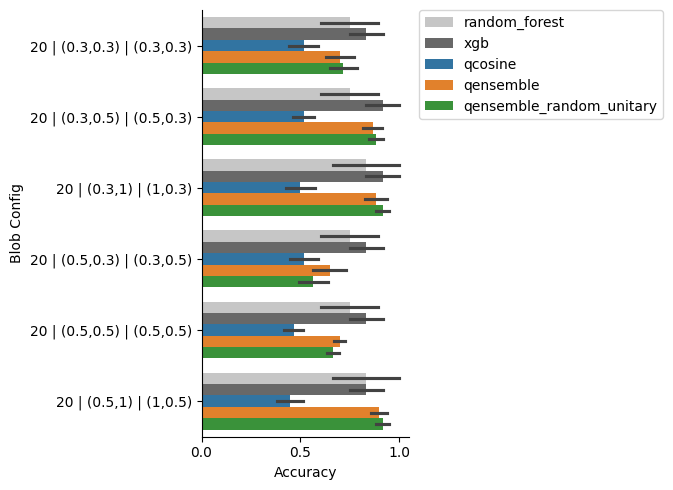

RF: blob : xgb (n=90) : t=3.933; p=0.0


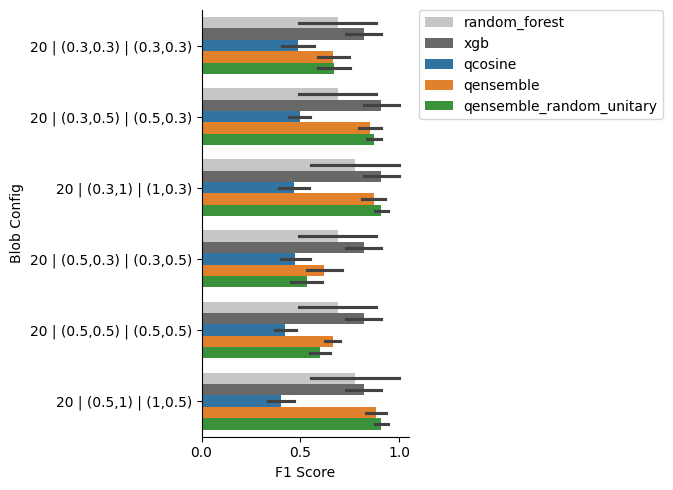

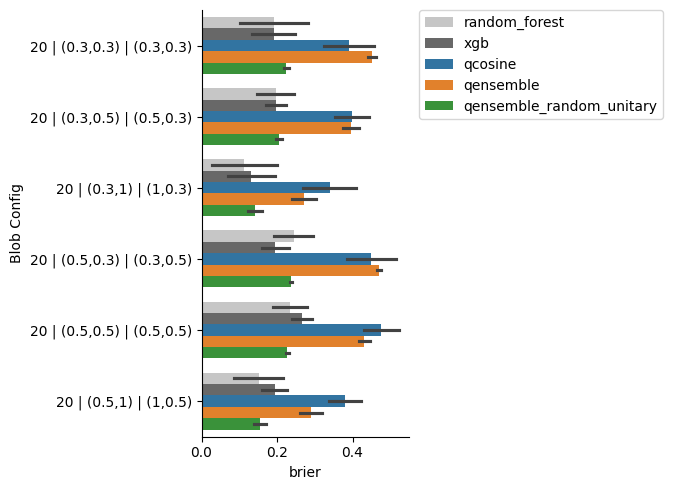

In [15]:
# Post-process results
total_results_full, sig_bestmethods_df = post_process_results(predictions, DIR_OUTPUT, datasets=['blob'])

## Conclusion

This tutorial demonstrated quantum ensemble learning for classification:

### Key Takeaways

1. **Quantum Advantage**: Ensemble methods leverage quantum superposition to evaluate multiple classifiers simultaneously
2. **Parameter Tuning**: Performance depends on careful selection of d, n_swap, and n_train
3. **Trade-offs**: Balance between accuracy improvement and computational cost
4. **Scalability**: Current methods limited by qubit count (~30-36 for simulation)

### Next Steps

- Test on real quantum hardware (IBM Quantum, etc.)
- Apply to real-world datasets
- Explore error mitigation techniques
- Investigate theoretical quantum advantage

### Further Reading

- See `README.md` for detailed documentation
- Check `modeling.py` and `modeling_random_unitary.py` for implementation details
- Refer to cited papers for theoretical background